Datasets :
1. [`FER2013`](https://www.kaggle.com/datasets/deadskull7/fer2013)
2. [`The Extended Cohn-Kanade Dataset (CK+)`](https://www.kaggle.com/datasets/davilsena/ckdataset)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from imblearn.over_sampling import RandomOverSampler
import seaborn as sns
import pickle
from tensorflow.keras import models

from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import Input
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, multilabel_confusion_matrix, precision_score, recall_score
from sklearn.model_selection import train_test_split
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.utils import plot_model

#**Prepare Data**

Import Datasets Paths


In [ ]:
FER_2013_PATH = "/kaggle/working/fer2013.csv"
CK_PATH = "/kaggle/working/ckextended.csv"

Explore the Data of the Both Dataset


In [ ]:
fer_2013_df = pd.read_csv(FER_2013_PATH)
ck_df = pd.read_csv(CK_PATH)
ck_df = ck_df.loc[ck_df["emotion"] != 7]
fer_2013_df.shape, ck_df.shape

((35887, 3), (902, 3))

In [ ]:
emotions_classes_dict = {0 : "Angry",
                         1 : "Disgust",
                         2 : "Fear",
                         3 : "Happy",
                         4 : "Sad",
                         5 : "Surprise",
                         6 : "Neutral"}
fer_2013_df["emotion_label"] = fer_2013_df["emotion"].map(emotions_classes_dict)
ck_df["emotion_label"] = ck_df["emotion"].map(emotions_classes_dict)
fer_2013_df.head()

,emotion,pixels,Usage,emotion_label
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...,Training,Angry
1,0,151 150 147 155 148 133 111 140 170 174 182 15...,Training,Angry
2,2,231 212 156 164 174 138 161 173 182 200 106 38...,Training,Fear
3,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...,Training,Sad
4,6,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...,Training,Neutral


In [ ]:
ck_df.head()

,emotion,pixels,Usage,emotion_label
0,6,36 39 35 25 19 11 8 7 3 13 15 9 21 57 75 90 10...,Training,Neutral
1,6,88 74 19 4 5 5 3 12 8 21 15 21 15 18 24 29 32 ...,Training,Neutral
2,6,9 2 4 7 1 1 1 0 7 29 49 76 115 141 156 169 177...,Training,Neutral
3,6,104 106 108 104 95 50 60 61 58 83 126 133 139 ...,Training,Neutral
4,6,68 72 67 67 6 2 1 1 1 1 1 14 24 24 38 65 79 94...,Training,Neutral



			fer_2013-dataset



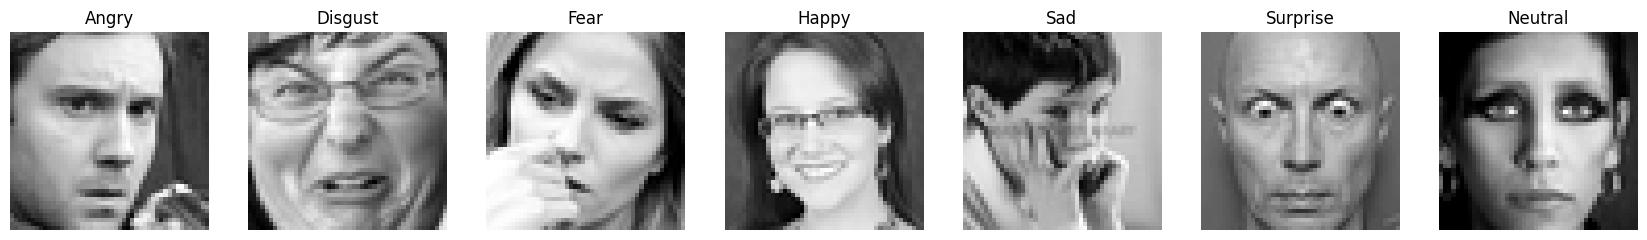


			ck-dataset



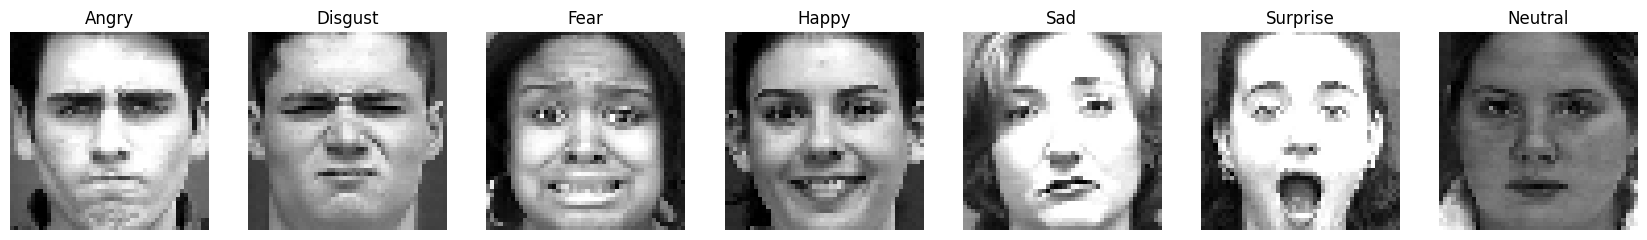

In [ ]:
def string_to_array(pixel_string, width, height):
    pixel_values = [int(x) for x in pixel_string.split()]
    return np.array(pixel_values).reshape(height, width)

def display_images(df):
    emotions = df["emotion"].unique()
    fig, axes = plt.subplots(1, len(emotions), figsize=(len(emotions) * 3, 3))
    for emotion, ax in zip(emotions, axes):
        emotion_df = df[df["emotion"] == emotion]
        pixel_string = emotion_df.iloc[0]["pixels"]
        image_array = string_to_array(pixel_string, 48, 48)
        ax.imshow(image_array, cmap="gray")
        ax.set_title(emotion)
        ax.axis("off")
    plt.show()

tmp_data = {
    "emotion": ["Angry", "Disgust", "Fear", "Happy", "Sad", "Surprise", "Neutral"],
    "pixels": [
        fer_2013_df["pixels"][0],fer_2013_df["pixels"][299],fer_2013_df["pixels"][2],
        fer_2013_df["pixels"][7],fer_2013_df["pixels"][3],fer_2013_df["pixels"][15],
        fer_2013_df["pixels"][4],
    ],
}
print("\n\t\t\tfer_2013-dataset\n")
tmp_df = pd.DataFrame(tmp_data)
display_images(tmp_df)

tmp_data = {
    "emotion": ["Angry", "Disgust", "Fear", "Happy", "Sad", "Surprise", "Neutral"],
    "pixels": [
        ck_df["pixels"][680], ck_df["pixels"][725],ck_df["pixels"][812],ck_df["pixels"][593],
        ck_df["pixels"][784],ck_df["pixels"][837],ck_df["pixels"][0],
    ],
}
print("\n\t\t\tck-dataset\n")
tmp_df = pd.DataFrame(tmp_data)
display_images(tmp_df)

Combining Data

In [ ]:
combined_df = pd.concat([fer_2013_df, ck_df],axis=0)
print('combined_df.shape =', combined_df.shape, '\n')
combined_df.shape

combined_df.shape = (36789, 4) 



(36789, 4)

In [ ]:
print("Unique emotions =", sorted(combined_df["emotion"].unique()), "\n")
print("Unique emotions =", sorted(combined_df["emotion_label"].unique()), "\n")
print(combined_df.emotion_label.value_counts(), "\n")

Unique emotions = [0, 1, 2, 3, 4, 5, 6] 

Unique emotions = ['Angry', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise'] 

emotion_label
Happy       9058
Neutral     6791
Sad         6105
Fear        5146
Angry       4998
Surprise    4085
Disgust      606
Name: count, dtype: int64 



In [ ]:
print("data =",sorted(combined_df.Usage.value_counts()))

data = [3678, 3682, 29429]


In [ ]:
print(combined_df.isnull().sum())

emotion          0
pixels           0
Usage            0
emotion_label    0
dtype: int64


Remove Duplicate Rows


In [ ]:
print('shape of combined df =', combined_df.shape)
print("duplicate tuples=", combined_df.duplicated().sum())
combined_df = combined_df.drop_duplicates()
print('without duplicate  =', combined_df.shape)

shape of combined df = (36789, 4)
duplicate tuples= 1234
without duplicate  = (35555, 4)


# **Visualize the Training and Testing Data**

In [ ]:
emotion_counts_by_usage  = combined_df.groupby(["Usage", "emotion"]).size().reset_index(name="Count")
emotion_counts_by_usage["emotion_label"] = emotion_counts_by_usage["emotion"].map(emotions_classes_dict)
emotion_counts_by_usage

,Usage,emotion,Count,emotion_label
0,PrivateTest,0,492,Angry
1,PrivateTest,1,61,Disgust
2,PrivateTest,2,528,Fear
3,PrivateTest,3,885,Happy
4,PrivateTest,4,595,Sad
5,PrivateTest,5,420,Surprise
6,PrivateTest,6,686,Neutral
7,PublicTest,0,468,Angry
8,PublicTest,1,61,Disgust
9,PublicTest,2,493,Fear


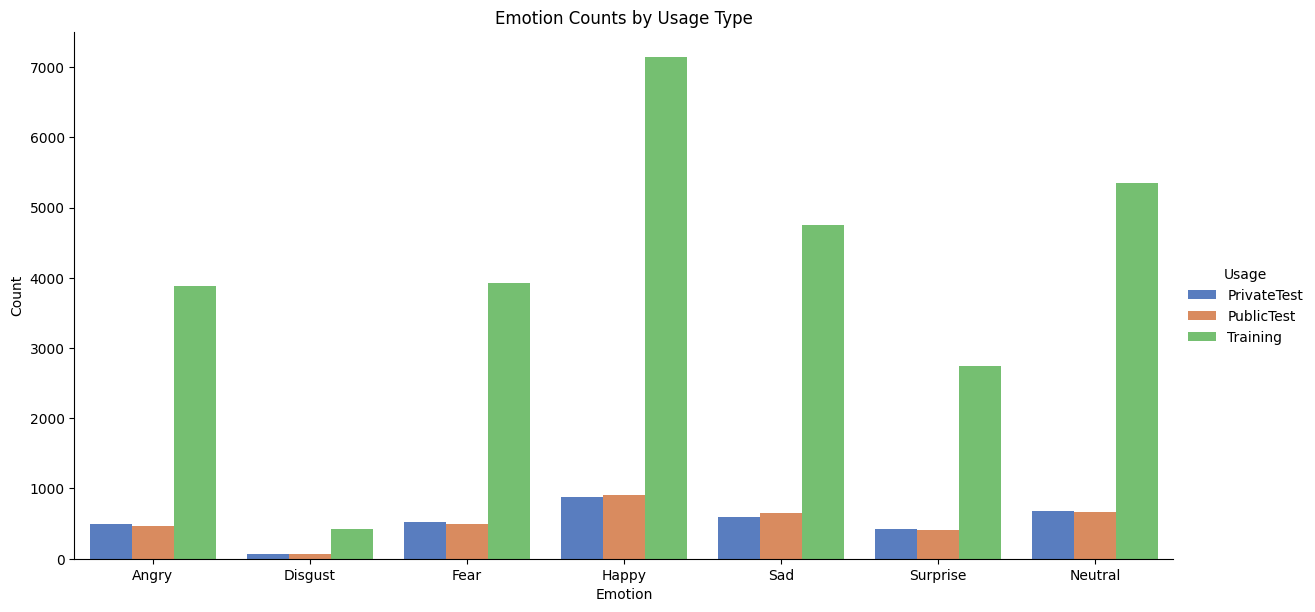

In [ ]:
g = sns.catplot(data=emotion_counts_by_usage, x="emotion", y="Count", hue="Usage", kind="bar", palette="muted", height=6, aspect=2)
g.set_xticklabels([emotions_classes_dict[int(t.get_text())] for t in g.ax.get_xticklabels()])
g.set_axis_labels("Emotion", "Count")
g.ax.set_title("Emotion Counts by Usage Type")
plt.show()

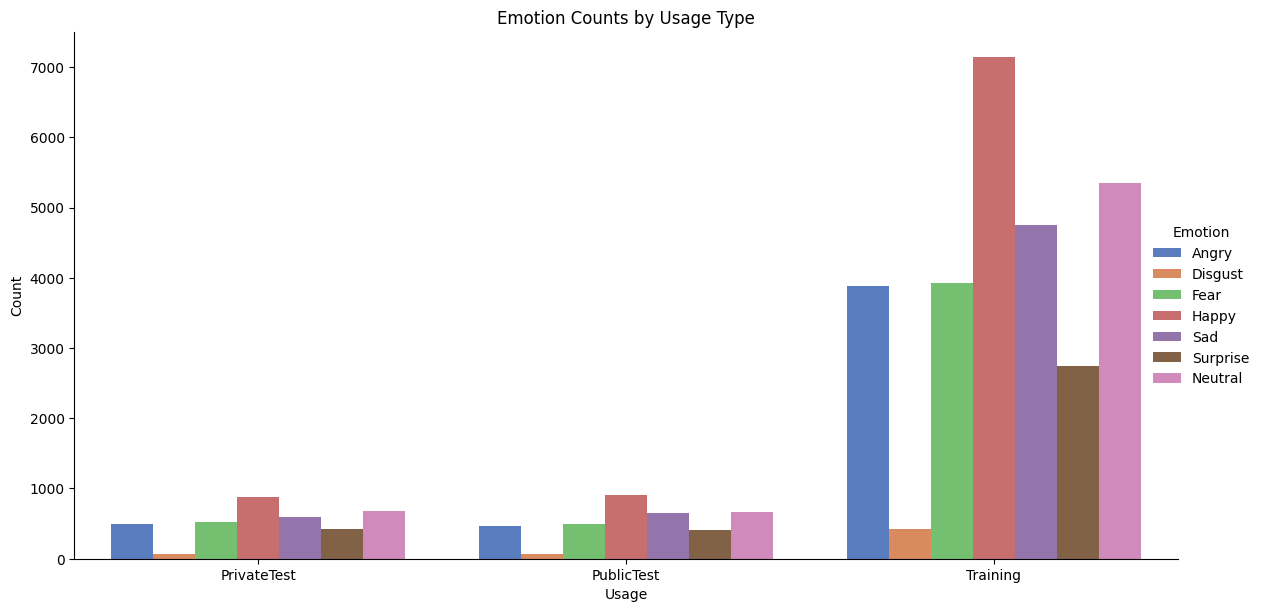

In [ ]:
g = sns.catplot(data=emotion_counts_by_usage, x="Usage", y="Count", hue="emotion", kind="bar", palette="muted", height=6, aspect=2)
g.legend.set_title("Emotion")

for t, l in zip(g.legend.texts, emotions_classes_dict.values()):
    t.set_text(l)

g.set_axis_labels("Usage", "Count")
g.ax.set_title("Emotion Counts by Usage Type")
plt.show()


Bar Chart and Pie Chart of the Unique Emotions


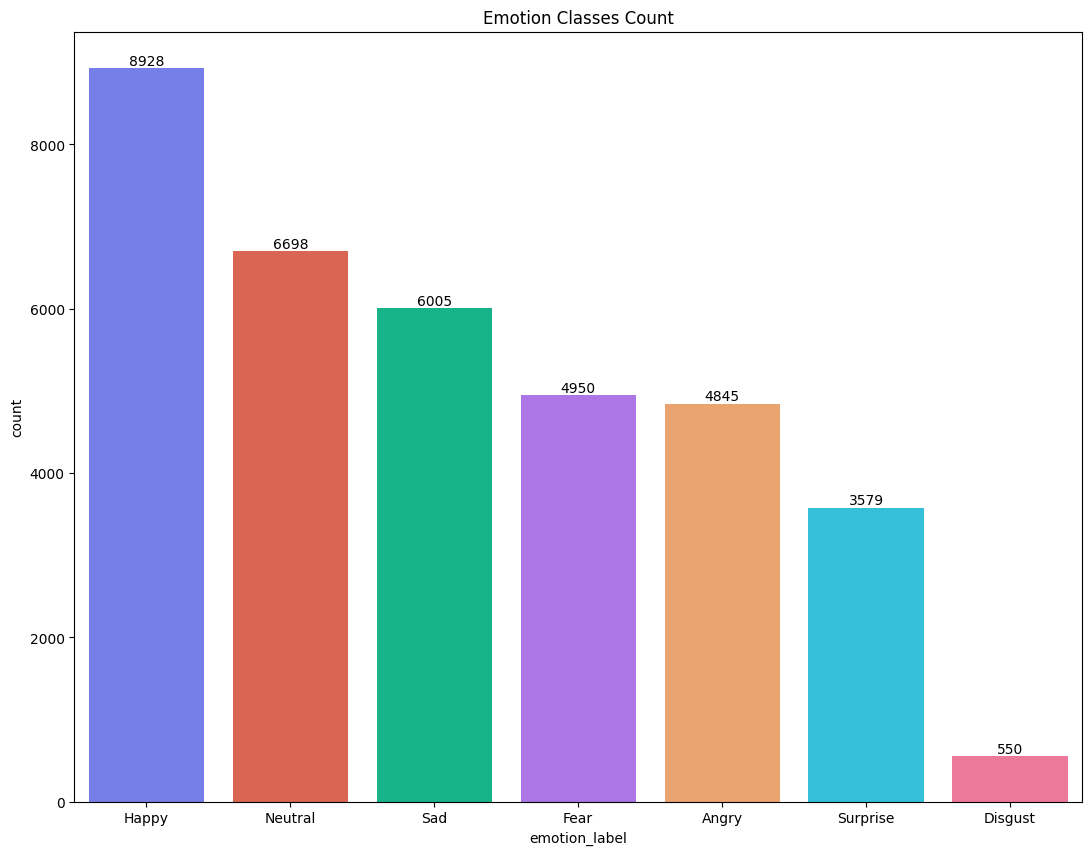

In [ ]:
plt.figure(figsize = (13,10))
plt.title("Emotion Classes Count")
ax = sns.countplot(data = combined_df, x = "emotion_label", order = combined_df["emotion_label"].value_counts().index, palette = ["#636efa", "#ef553b", "#00cc96", "#ab63fa", "#ffa15a", "#19d3f3", "#ff6692"])
ax.bar_label(ax.containers[0])
plt.show()

# Split Data For Model

In [ ]:
emotions_classes_label = sorted(combined_df["emotion_label"].unique())

In [ ]:
X = combined_df["pixels"]
X.shape

(35555,)

In [ ]:
y = combined_df["emotion"]
y.value_counts(), y.shape

(emotion
 3    8928
 6    6698
 4    6005
 2    4950
 0    4845
 5    3579
 1     550
 Name: count, dtype: int64,
 (35555,))

In [ ]:
oversampler = RandomOverSampler(sampling_strategy="auto")
X, y = oversampler.fit_resample(X.values.reshape(-1,1), y)

In [ ]:
print("X.shape =", X.shape)
print("y.shape =", y.shape)

X.shape = (62496, 1)
y.shape = (62496,)


In [ ]:
X = pd.Series(X.flatten())
X

0        70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...
1        151 150 147 155 148 133 111 140 170 174 182 15...
2        231 212 156 164 174 138 161 173 182 200 106 38...
3        24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...
4        4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...
                               ...                        
62491    76 70 40 44 66 59 58 87 117 135 145 160 174 18...
62492    26 30 41 64 78 98 110 117 121 129 130 145 151 ...
62493    119 125 158 191 183 197 211 206 203 177 174 19...
62494    7 7 8 9 46 60 54 54 55 59 60 60 50 51 58 59 63...
62495    117 89 8 26 45 68 87 45 50 78 60 21 11 34 58 6...
Length: 62496, dtype: object

In [ ]:
X = np.array(list(map(str.split, X)), np.float32)
X /= 255
X[:10]

array([[0.27450982, 0.3137255 , 0.32156864, ..., 0.41568628, 0.42745098,
        0.32156864],
       [0.5921569 , 0.5882353 , 0.5764706 , ..., 0.75686276, 0.7176471 ,
        0.72156864],
       [0.90588236, 0.83137256, 0.6117647 , ..., 0.34509805, 0.43137255,
        0.59607846],
       ...,
       [0.3019608 , 0.30588236, 0.30980393, ..., 0.49019608, 0.2627451 ,
        0.26666668],
       [0.33333334, 0.32941177, 0.3529412 , ..., 0.22745098, 0.28627452,
        0.32941177],
       [1.        , 0.99607843, 1.        , ..., 0.99607843, 1.        ,
        1.        ]], dtype=float32)

In [ ]:
print(X.shape)
X = X.reshape(-1, 48, 48, 1)
X.shape

(62496, 2304)


(62496, 48, 48, 1)

In [ ]:
y = np.array(y)
y = y.reshape(y.shape[0], 1)
y

array([[0],
       [0],
       [2],
       ...,
       [6],
       [6],
       [6]])

In [ ]:
X_train, X_remain, y_train, y_remain = train_test_split(
    X, y, test_size = 0.2, random_state = 42)
X_valid, X_test, y_valid, y_test = train_test_split(
    X_remain, y_remain, test_size = 0.5, random_state = 42)

print("X_train.shape  = ", X_train.shape)
print("X_valid.shape  = ", X_valid.shape)
print("X_test.shape   = ", X_test.shape)
print()
print("y_train.shape  = ", y_train.shape)
print("y_valid.shape  = ", y_valid.shape)
print("y_test.shape   = ", y_test.shape)


X_train.shape  =  (49996, 48, 48, 1)
X_valid.shape  =  (6250, 48, 48, 1)
X_test.shape   =  (6250, 48, 48, 1)

y_train.shape  =  (49996, 1)
y_valid.shape  =  (6250, 1)
y_test.shape   =  (6250, 1)


In [ ]:
from tensorflow.keras.utils import to_categorical
y_train = to_categorical(y_train, 7)
y_valid = to_categorical(y_valid, 7)
y_test = to_categorical(y_test, 7)
y_train.shape , y_valid.shape ,y_test.shape

((49996, 7), (6250, 7), (6250, 7))

Callback Functions


# CNN

In [ ]:
early_stopping = EarlyStopping(monitor="val_accuracy", patience=10, mode="auto", restore_best_weights=True)
reduce_learning_rate = ReduceLROnPlateau(monitor="val_accuracy", factor=0.5, verbose=1, min_lr=0.00001)

In [ ]:
model = models.Sequential()

# CNN Layers
model.add(Input((48, 48, 1)))  # Input layer for 48x48 grayscale images
model.add(layers.Conv2D(32, kernel_size=(3, 3), strides=(1, 1), padding="valid"))
model.add(layers.BatchNormalization(axis=3))
model.add(layers.Activation("relu"))

model.add(layers.Conv2D(64, (3, 3), strides=(1, 1), padding="same"))
model.add(layers.BatchNormalization(axis=3))
model.add(layers.Activation("relu"))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(128, (3, 3), strides=(1, 1), padding="same"))
model.add(layers.BatchNormalization(axis=3))
model.add(layers.Activation("relu"))
model.add(layers.MaxPooling2D((2, 2)))

# Flatten the output to feed into a fully connected layer
model.add(layers.Flatten())

# Fully connected layers (classifier)
model.add(layers.Dense(128, activation="relu"))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(7, activation="softmax"))  # 7 output classes

In [ ]:
adam_optimizer = Adam(learning_rate=0.0002)
model.compile(optimizer=adam_optimizer, loss="categorical_crossentropy", metrics=["accuracy"])

# Print the model summary
print(model.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 46, 46, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 46, 46, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 46, 46, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 46, 46, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 46, 46, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 23, 23, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 23, 23, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 11, 11, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 15488)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,982,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,077,063 (7.92 MB)

 Trainable params: 2,076,615 (7.92 MB)

 Non-trainable params: 448 (1.75 KB)

None


In [ ]:
plot_model(model, to_file="cnn_simple_classifier.png", show_shapes=True, show_dtype=True)

In [ ]:
history_callback_object = model.fit(x=X_train, y=y_train, epochs=100,
                                    callbacks=[early_stopping, reduce_learning_rate],
                                    validation_data=(X_valid, y_valid),batch_size=128)

Epoch 1/100


I0000 00:00:1728246639.625016     180 service.cc:145] XLA service 0x7834d80068b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1728246639.625075     180 service.cc:153]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1728246639.625080     180 service.cc:153]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5


  5/391 ━━━━━━━━━━━━━━━━━━━━ 14s 39ms/step - accuracy: 0.1536 - loss: 2.9930

I0000 00:00:1728246646.000293     180 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


391/391 ━━━━━━━━━━━━━━━━━━━━ 25s 41ms/step - accuracy: 0.1962 - loss: 1.9758 - val_accuracy: 0.1701 - val_loss: 1.9621 - learning_rate: 2.0000e-04
Epoch 2/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.2615 - loss: 1.7993 - val_accuracy: 0.3725 - val_loss: 1.6742 - learning_rate: 2.0000e-04
Epoch 3/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.3007 - loss: 1.7421 - val_accuracy: 0.4453 - val_loss: 1.6247 - learning_rate: 2.0000e-04
Epoch 4/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - accuracy: 0.3222 - loss: 1.6988 - val_accuracy: 0.4558 - val_loss: 1.5909 - learning_rate: 2.0000e-04
Epoch 5/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - accuracy: 0.3306 - loss: 1.6691 - val_accuracy: 0.5046 - val_loss: 1.5275 - learning_rate: 2.0000e-04
Epoch 6/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - accuracy: 0.3427 - loss: 1.6362 - val_accuracy: 0.5117 - val_loss: 1.4766 - learning_rate: 2.0000e-04
Epoch 7/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - a

In [ ]:
file_path_model = "./cnn_simple_classifier_model.h5"
model.save(file_path_model)

Model Loss & Accuracy Plot



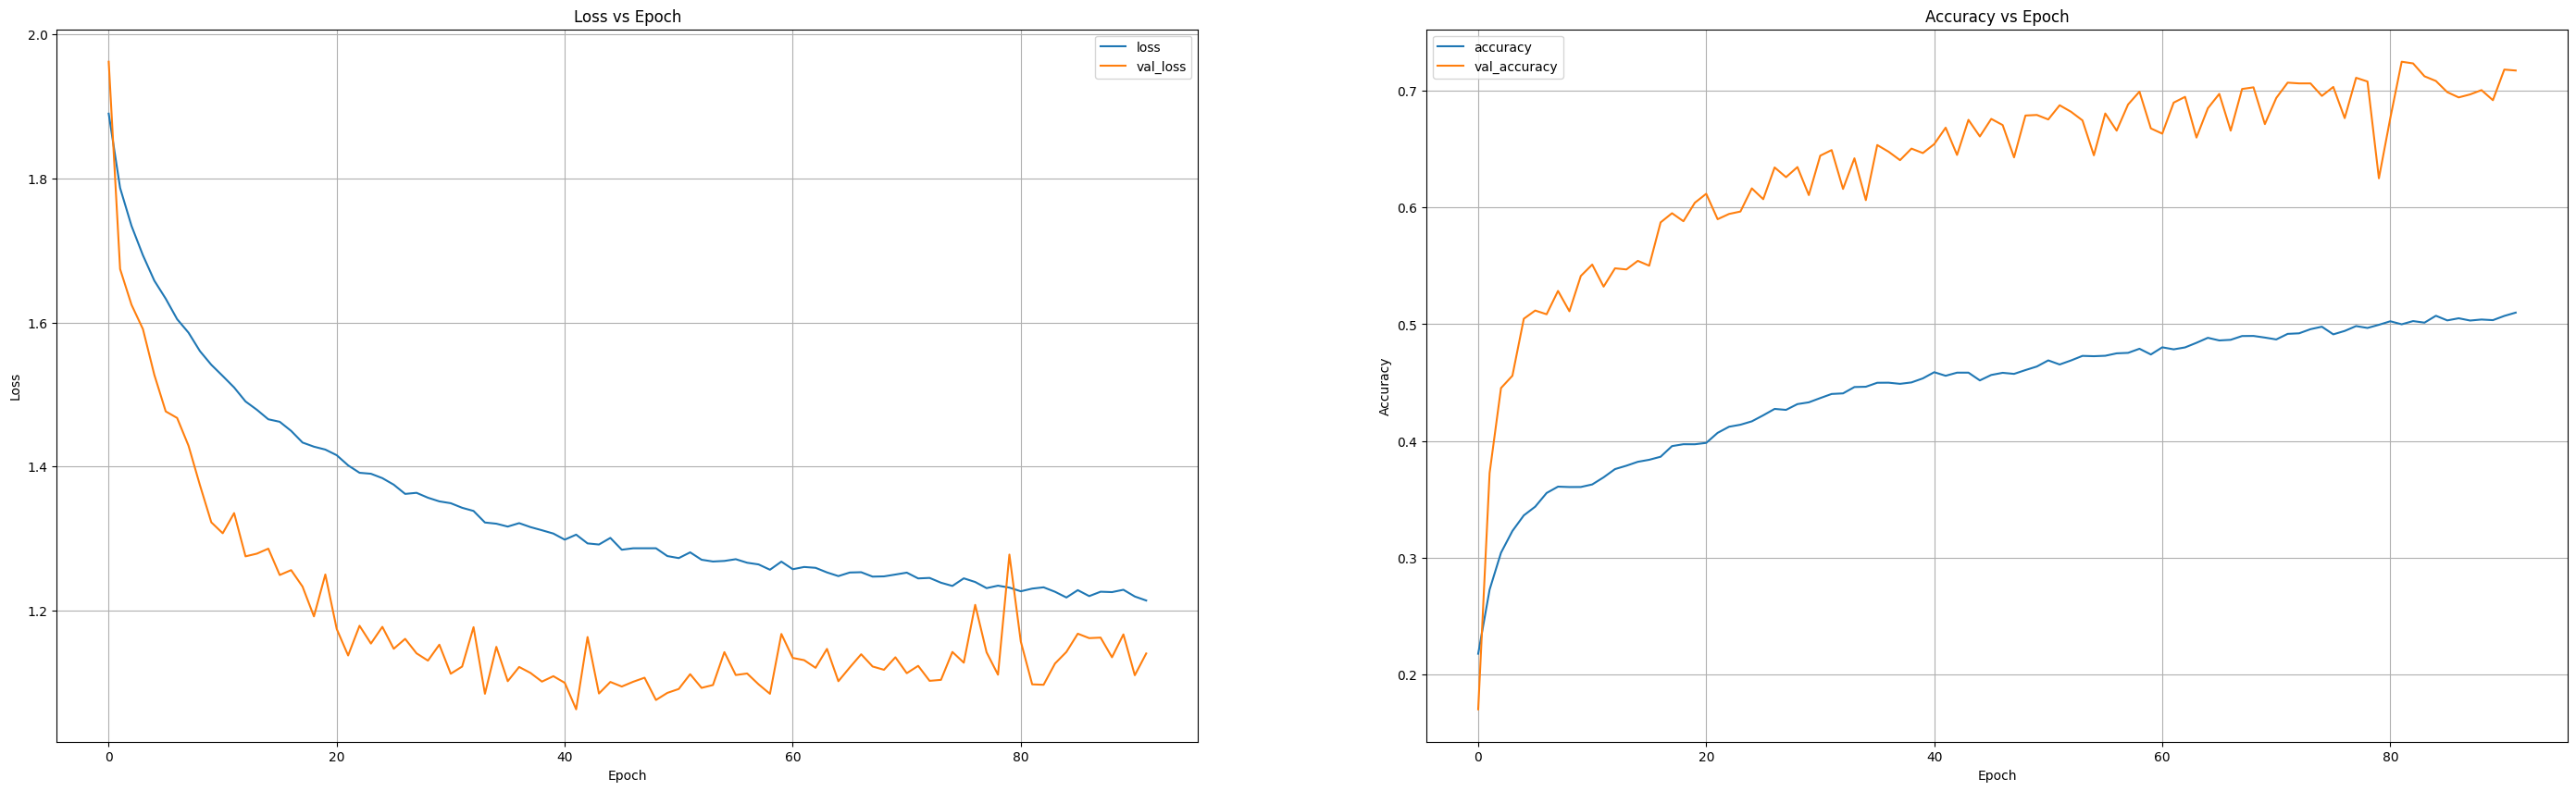

In [ ]:
print("Model Loss & Accuracy Plot\n")
fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.plot(history_callback_object.history["loss"], label="loss")
ax1.plot(history_callback_object.history["val_loss"], label="val_loss")
ax1.legend()
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Loss vs Epoch")
ax1.grid(True)

ax2.plot(history_callback_object.history["accuracy"], label="accuracy")
ax2.plot(history_callback_object.history["val_accuracy"], label="val_accuracy")
ax2.legend()
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Accuracy vs Epoch")
ax2.grid(True)

fig.set_figheight(10)
fig.set_figwidth(35)
plt.show()

In [ ]:
y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)
y_test_labels = np.argmax(y_test, axis=1)
y_test_labels[0]

196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


1

In [ ]:
print("Accuracy of model on testing data: ", model.evaluate(X_test, y_test)[1] * 100, "%")

196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7202 - loss: 1.0848
Accuracy of model on testing data:  72.64000177383423 %


In [ ]:
print("Confusion Matrix:\n", confusion_matrix(y_test_labels, y_pred))

Confusion Matrix:
 [[618   6  46  33 134  13  27]
 [ 58 847   0   0   0   0   0]
 [ 94   7 526  27 160  39  20]
 [ 93   3  26 604  50  22 120]
 [106   1  54  28 568   5  66]
 [ 23   1  47  15   9 835   3]
 [ 65   0  38  72 187  12 542]]


In [ ]:
print("Model Classification Report\n", classification_report(y_test_labels, y_pred, target_names=["Angry", "Disgust", "Fear", "Happy", "Sad", "Surprise", "Neutral"]))

Model Classification Report
               precision    recall  f1-score   support

       Angry       0.58      0.70      0.64       877
     Disgust       0.98      0.94      0.96       905
        Fear       0.71      0.60      0.65       873
       Happy       0.78      0.66      0.71       918
         Sad       0.51      0.69      0.59       828
    Surprise       0.90      0.89      0.90       933
     Neutral       0.70      0.59      0.64       916

    accuracy                           0.73      6250
   macro avg       0.74      0.72      0.73      6250
weighted avg       0.74      0.73      0.73      6250



# CNN-LSTM

In [ ]:
early_stopping = EarlyStopping(monitor = "val_accuracy",
                               patience = 10,
                               mode = "auto",
                               restore_best_weights = True)
reduce_learning_rate = ReduceLROnPlateau(monitor ="val_accuracy",
                                         factor = 0.5,
                                         verbose = 1,
                                         min_lr = 0.00001)

In [ ]:
model = models.Sequential()

model.add(Input((48, 48, 1)))
model.add(layers.Conv2D(32, kernel_size=(3, 3), strides=(1, 1), padding="valid"))
model.add(layers.BatchNormalization(axis=3))
model.add(layers.Activation("relu"))

model.add(layers.Conv2D(64, (3, 3), strides=(1, 1), padding="same"))
model.add(layers.BatchNormalization(axis=3))
model.add(layers.Activation("relu"))

model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(64, (3, 3), strides=(1, 1), padding="valid"))
model.add(layers.BatchNormalization(axis=3))
model.add(layers.Activation("relu"))

model.add(layers.Conv2D(128, (3, 3), strides=(1, 1), padding="same"))
model.add(layers.BatchNormalization(axis=3))
model.add(layers.Activation("relu"))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(128, (3, 3), strides=(1, 1), padding="valid"))
model.add(layers.BatchNormalization(axis=3))
model.add(layers.Activation("relu"))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Reshape((-1, 128)))

model.add(layers.LSTM(128))

model.add(layers.Reshape((-1, 64)))

model.add(layers.LSTM(64))

model.add(layers.Dense(200, activation="relu"))

model.add(layers.Dropout(0.6))

model.add(layers.Dense(7, activation="softmax"))

adam_optimizer = Adam(learning_rate=0.0002)

model.compile(optimizer = adam_optimizer, loss = "categorical_crossentropy", metrics=["accuracy"])

print(model.summary())


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 46, 46, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 46, 46, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 46, 46, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 46, 46, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 46, 46, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 46, 46, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 23, 23, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 21, 21, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 21, 21, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 21, 21, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 21, 21, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 21, 21, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 21, 21, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 10, 10, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 8, 8, 128)           │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 8, 8, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_4 (Activation)            │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 4, 4, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape (Reshape)                    │ (None, 16, 128)             │              

 Total params: 457,863 (1.75 MB)

 Trainable params: 457,031 (1.74 MB)

 Non-trainable params: 832 (3.25 KB)

None


In [ ]:
plot_model(model, to_file = "Cnn-with-lstm.png", show_shapes = True, show_dtype = True)

In [ ]:
history_callback_object = model.fit(x=X_train, y=y_train, epochs = 100, callbacks=[early_stopping, reduce_learning_rate], validation_data=(X_valid, y_valid))


Epoch 1/100
1563/1563 [==============================] - 30s 13ms/step - loss: 1.5329 - accuracy: 0.4057 - val_loss: 1.2963 - val_accuracy: 0.5045 - lr: 2.0000e-04
Epoch 2/100
1563/1563 [==============================] - 19s 12ms/step - loss: 1.0955 - accuracy: 0.5793 - val_loss: 1.1046 - val_accuracy: 0.5662 - lr: 2.0000e-04
Epoch 3/100
1563/1563 [==============================] - 19s 12ms/step - loss: 0.9284 - accuracy: 0.6485 - val_loss: 1.0462 - val_accuracy: 0.6122 - lr: 2.0000e-04
Epoch 4/100
1563/1563 [==============================] - 19s 12ms/step - loss: 0.8116 - accuracy: 0.6998 - val_loss: 0.9215 - val_accuracy: 0.6555 - lr: 2.0000e-04
Epoch 5/100
1563/1563 [==============================] - 19s 12ms/step - loss: 0.7030 - accuracy: 0.7468 - val_loss: 0.8160 - val_accuracy: 0.7045 - lr: 2.0000e-04
Epoch 6/100
1563/1563 [==============================] - 19s 12ms/step - loss: 0.6009 - accuracy: 0.7891 - val_loss: 0.8139 - val_accuracy: 0.6926 - lr: 2.0000e-04
Epoch 7/100
1563

Save the Model


In [ ]:
file_path_model = "./model.h5"
model.save(file_path_model)

model_json = model.to_json()
with open("model.json", "w") as json_file:
    json_file.write(model_json)

model.save_weights("model_weights.h5")
print("The model has been successfully saved. ")

The model has been successfully saved. 


 Model Loss and Accuracy Plot


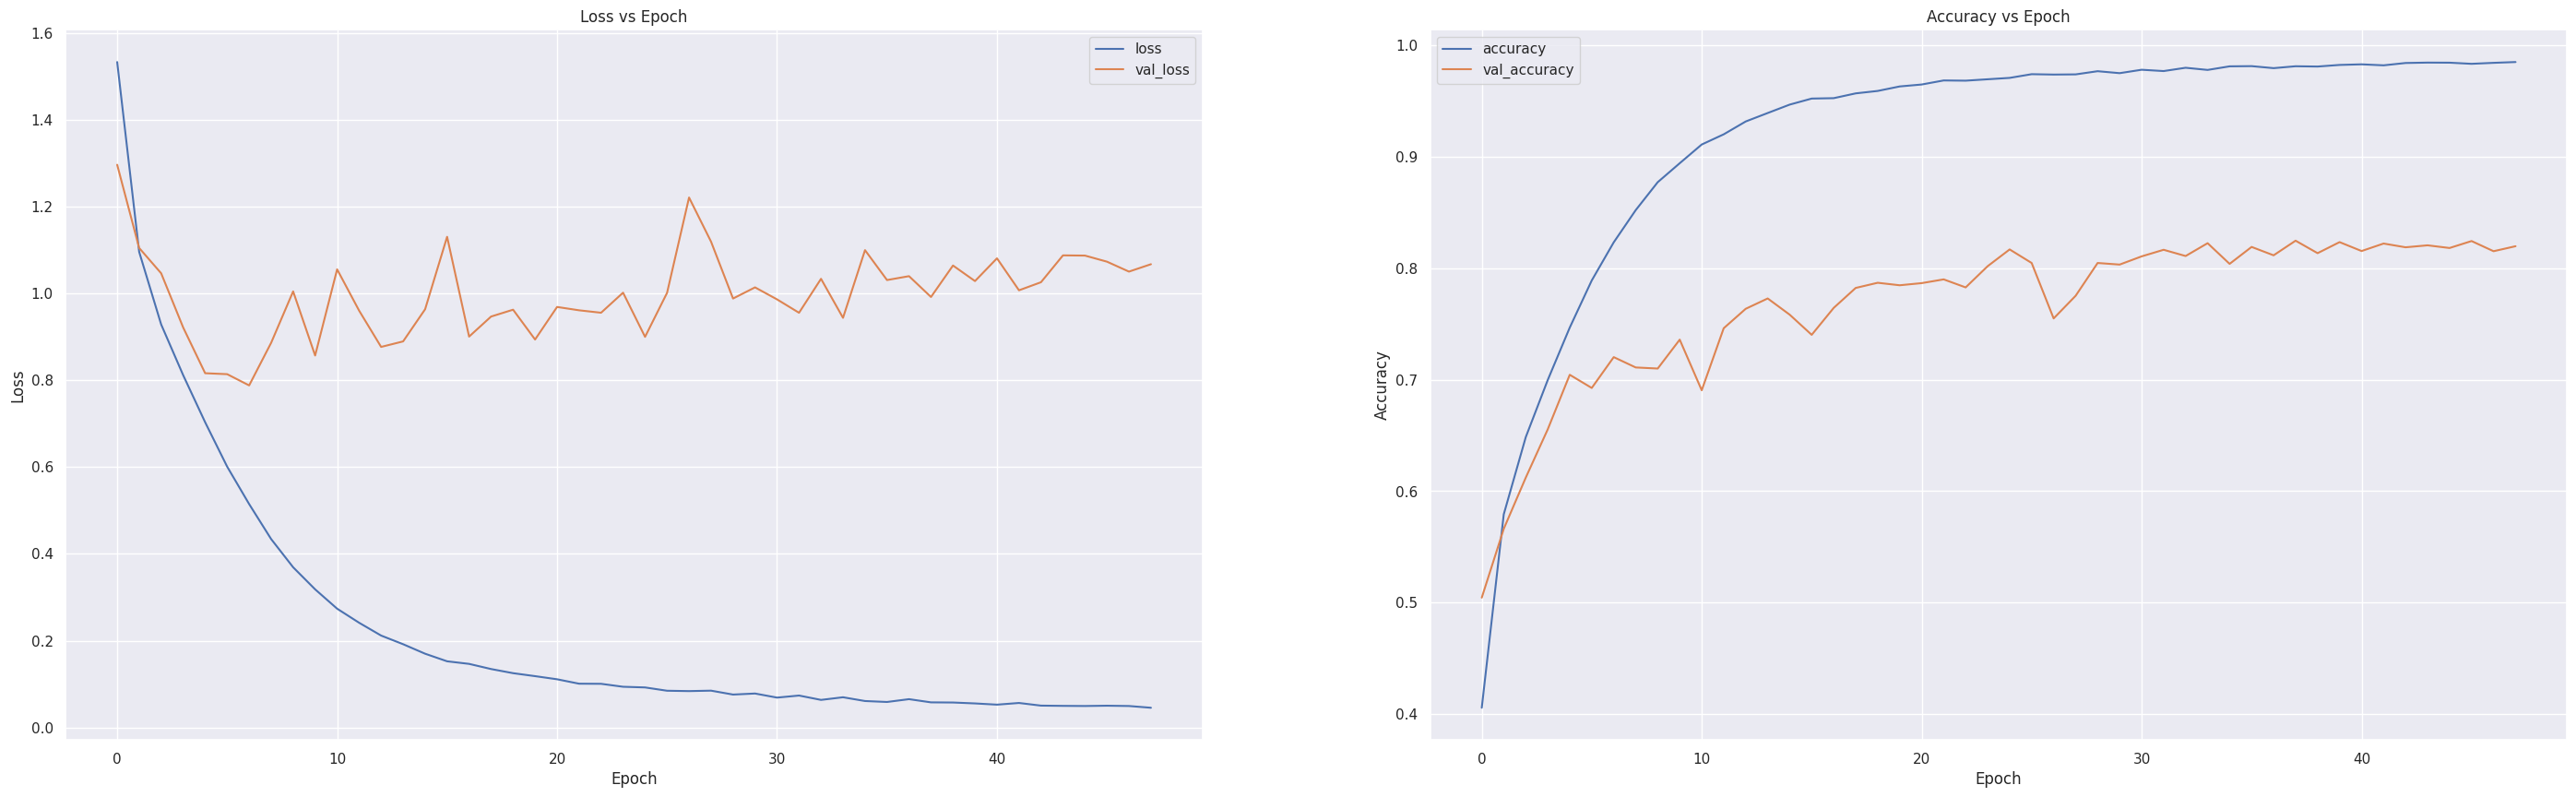

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy', 'lr'])

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.plot(history_callback_object.history["loss"], label = "loss")
ax1.plot(history_callback_object.history["val_loss"], label = "val_loss")
ax1.legend()
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Loss vs Epoch")
ax1.grid(True)

ax2.plot(history_callback_object.history["accuracy"], label = "accuracy")
ax2.plot(history_callback_object.history["val_accuracy"], label = "val_accuracy")
ax2.legend()
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Accuracy vs Epoch")
ax2.grid(True)

fig.set_figheight(10)
fig.set_figwidth(35)
plt.show()

history_callback_object.history.keys()

Predictions Using Our Testing Data


In [ ]:
y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis = 1)
print(y_pred[0])

196/196 ━━━━━━━━━━━━━━━━━━━━ 34s 174ms/step

5


In [ ]:
print("Accuracy of model on testing data: ", model.evaluate(X_test, y_test)[1] * 100 , "%", sep = "")

196/196 [==============================] - 1s 5ms/step - loss: 0.9956 - accuracy: 0.8245
Accuracy of model on testing data: 82.44799971580505%


In [ ]:
print("Accuracy of model on validation data: ", model.evaluate(X_valid, y_valid)[1] * 100 , "%", sep = "")

196/196 [==============================] - 1s 6ms/step - loss: 0.9917 - accuracy: 0.8248
Accuracy of model on validation data: 82.48000144958496%


In [ ]:
model_loss, model_accuracy = model.evaluate(X_test, y_test)

print("Model Test Loss: %f" % (model_loss))
print("Model Test Loss: %f" % (model_loss * 100), "%\n", sep = "")
print("Model Test Accuracy: %f" % (model_accuracy))
print("Model Test Accuracy: %f" % (model_accuracy * 100), "%", sep = "")


196/196 [==============================] - 1s 6ms/step - loss: 0.9956 - accuracy: 0.8245
Model Test Loss: 0.995630
Model Test Loss: 99.562991%

Model Test Accuracy: 0.824480
Model Test Accuracy: 82.448000%


In [ ]:
accuracy = accuracy_score(y_check, y_pred)
precision = precision_score(y_check, y_pred, average = "micro")
recall = recall_score(y_check, y_pred, average = "micro")
f1 = f1_score(y_check, y_pred, average = "micro")

print("Accuracy Score: %f" % (accuracy * 100), "%", sep = "")
print("Precision Score: %f" % (precision * 100), "%", sep = "")
print("Recall Score: %f" % (recall * 100), "%", sep = "")
print("F1 Score: %f" % (f1 * 100), "%", sep = "")

Accuracy Score: 82.448000%
Precision Score: 82.448000%
Recall Score: 82.448000%
F1 Score: 82.448000%


Confusion Matrix


[[[5143  230]
  [ 156  721]]

 [[5322   23]
  [   0  905]]

 [[5231  146]
  [ 243  630]]

 [[5162  170]
  [ 159  759]]

 [[5206  216]
  [ 248  580]]

 [[5224   93]
  [  46  887]]

 [[5115  219]
  [ 245  671]]] 



          Angry  Disgust  Fear  Happy  Neutral  Sad  Surprise
Angry       721       10    26     23       52   10        35
Disgust       0      905     0      0        0    0         0
Fear         62        4   630     25       56   46        50
Happy        39        0    17    759       34   21        48
Neutral      63        4    58     42      580    3        78
Sad           4        2    15     11        6  887         8
Surprise     62        3    30     69       68   13       671 



0=Angry, 1=Disgust, 2=Fear, 3=Happy, 4=Sad, 5=Surprise, 6=Neutral



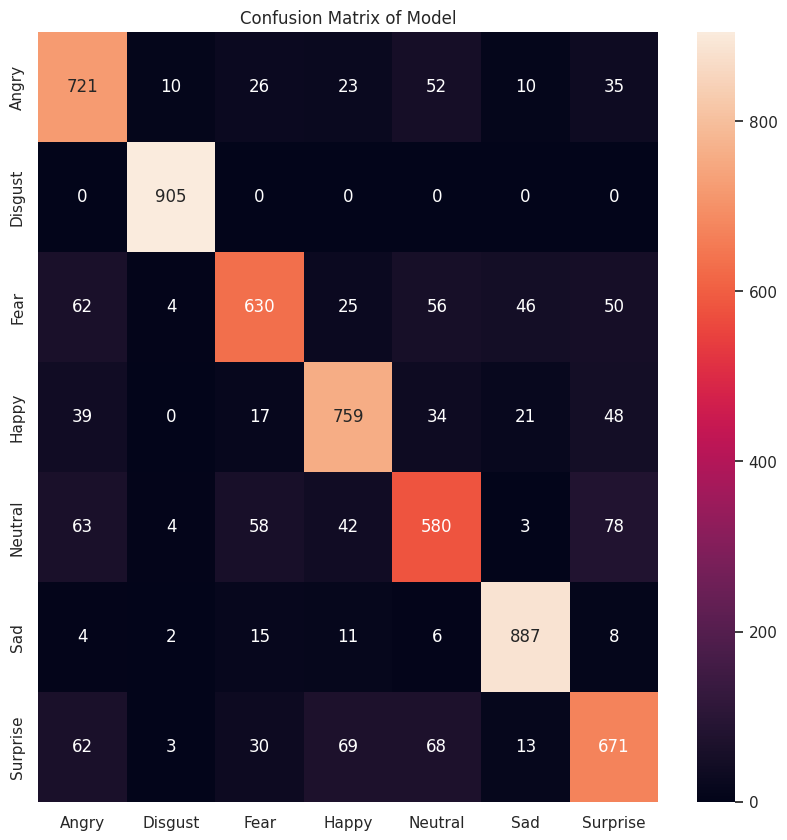

In [ ]:
fig = plt.figure(figsize=(10, 10))
plt.title("Confusion Matrix of Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")

cm = multilabel_confusion_matrix(y_check, y_pred)
print(cm, "\n\n\n")

model_matrix = confusion_matrix(y_check, y_pred)
cm = pd.DataFrame(model_matrix,
                  index = [i for i in emotions_classes_label],
                  columns = [i for i in emotions_classes_label]
                 )

ax = sns.heatmap(cm,
                 annot = True,
                 fmt = "d",cbar=True)

print(cm, "\n\n\n")
print("0=Angry, 1=Disgust, 2=Fear, 3=Happy, 4=Sad, 5=Surprise, 6=Neutral\n")
plt.show()

Classification Report


In [ ]:
y_pred = model.predict(X_test)
y_result = []
y_actual = []

for pred in y_pred:
    y_result.append(np.argmax(pred))

for pred in y_test:
    y_actual.append(np.argmax(pred))


196/196 [==============================] - 1s 4ms/step


In [ ]:
print("Model Classification Report\n", classification_report(y_actual, y_result))

Model Classification Report
               precision    recall  f1-score   support

           0       0.76      0.82      0.79       877
           1       0.98      1.00      0.99       905
           2       0.81      0.72      0.76       873
           3       0.82      0.83      0.82       918
           4       0.73      0.70      0.71       828
           5       0.91      0.95      0.93       933
           6       0.75      0.73      0.74       916

    accuracy                           0.82      6250
   macro avg       0.82      0.82      0.82      6250
weighted avg       0.82      0.82      0.82      6250



# CNN-BiLSTM

In [ ]:
early_stopping = EarlyStopping(monitor="val_accuracy", patience=10, mode="auto", restore_best_weights=True)
reduce_learning_rate = ReduceLROnPlateau(monitor="val_accuracy", factor=0.5, verbose=1, min_lr=0.00001)

In [ ]:
model = models.Sequential()

# CNN Layers
model.add(Input((48, 48, 1)))
model.add(layers.Conv2D(32, kernel_size=(3, 3), strides=(1, 1), padding="valid"))
model.add(layers.BatchNormalization(axis=3))
model.add(layers.Activation("relu"))

model.add(layers.Conv2D(64, (3, 3), strides=(1, 1), padding="same"))
model.add(layers.BatchNormalization(axis=3))
model.add(layers.Activation("relu"))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(64, (3, 3), strides=(1, 1), padding="valid"))
model.add(layers.BatchNormalization(axis=3))
model.add(layers.Activation("relu"))

model.add(layers.Conv2D(128, (3, 3), strides=(1, 1), padding="same"))
model.add(layers.BatchNormalization(axis=3))
model.add(layers.Activation("relu"))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(128, (3, 3), strides=(1, 1), padding="valid"))
model.add(layers.BatchNormalization(axis=3))
model.add(layers.Activation("relu"))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Reshape((-1, 128)))

model.add(layers.Bidirectional(layers.LSTM(128, return_sequences=True)))
model.add(layers.Bidirectional(layers.LSTM(64)))

model.add(layers.Dense(200, activation="relu"))
model.add(layers.Dropout(0.6))
model.add(layers.Dense(7, activation="softmax"))

adam_optimizer = Adam(learning_rate=0.0002)
model.compile(optimizer=adam_optimizer, loss="categorical_crossentropy", metrics=["accuracy"])

print(model.summary())

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 46, 46, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 46, 46, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 46, 46, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 46, 46, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 46, 46, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 21, 21, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 21, 21, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 21, 21, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 21, 21, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 21, 21, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 16, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 16, 256)        │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 200)            │        25,800 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 733,575 (2.80 MB)

 Trainable params: 732,743 (2.80 MB)

 Non-trainable params: 832 (3.25 KB)

None


In [ ]:
plot_model(model, to_file="cnn_bilstm.png", show_shapes=True, show_dtype=True)

In [ ]:
history_callback_object = model.fit(x=X_train, y=y_train, epochs=100,
                                    callbacks=[early_stopping, reduce_learning_rate],
                                    validation_data=(X_valid, y_valid))

Epoch 1/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 51s 26ms/step - accuracy: 0.3037 - loss: 1.7304 - val_accuracy: 0.5086 - val_loss: 1.2939 - learning_rate: 2.0000e-04
Epoch 2/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 40s 26ms/step - accuracy: 0.5688 - loss: 1.1333 - val_accuracy: 0.5746 - val_loss: 1.1191 - learning_rate: 2.0000e-04
Epoch 3/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 26ms/step - accuracy: 0.6427 - loss: 0.9424 - val_accuracy: 0.6395 - val_loss: 0.9422 - learning_rate: 2.0000e-04
Epoch 4/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 42s 27ms/step - accuracy: 0.6926 - loss: 0.8258 - val_accuracy: 0.6795 - val_loss: 0.8671 - learning_rate: 2.0000e-04
Epoch 5/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 26ms/step - accuracy: 0.7312 - loss: 0.7305 - val_accuracy: 0.6467 - val_loss: 1.0038 - learning_rate: 2.0000e-04
Epoch 6/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 40s 26ms/step - accuracy: 0.7747 - loss: 0.6256 - val_accuracy: 0.6896 - val_loss: 0.8710 - learning_rate: 2.0000e-04
Epoch 7/100
1563/1563 ━━━━━━━━━━━━

In [ ]:
file_path_model = "./cnn_bilstm_model.h5"
model.save(file_path_model)

model_json = model.to_json()
with open("cnn_bilstm_model.json", "w") as json_file:
    json_file.write(model_json)

model.save_weights("cnn_bilstm_weights.weights.h5")
print("The model has been successfully saved.")

The model has been successfully saved.


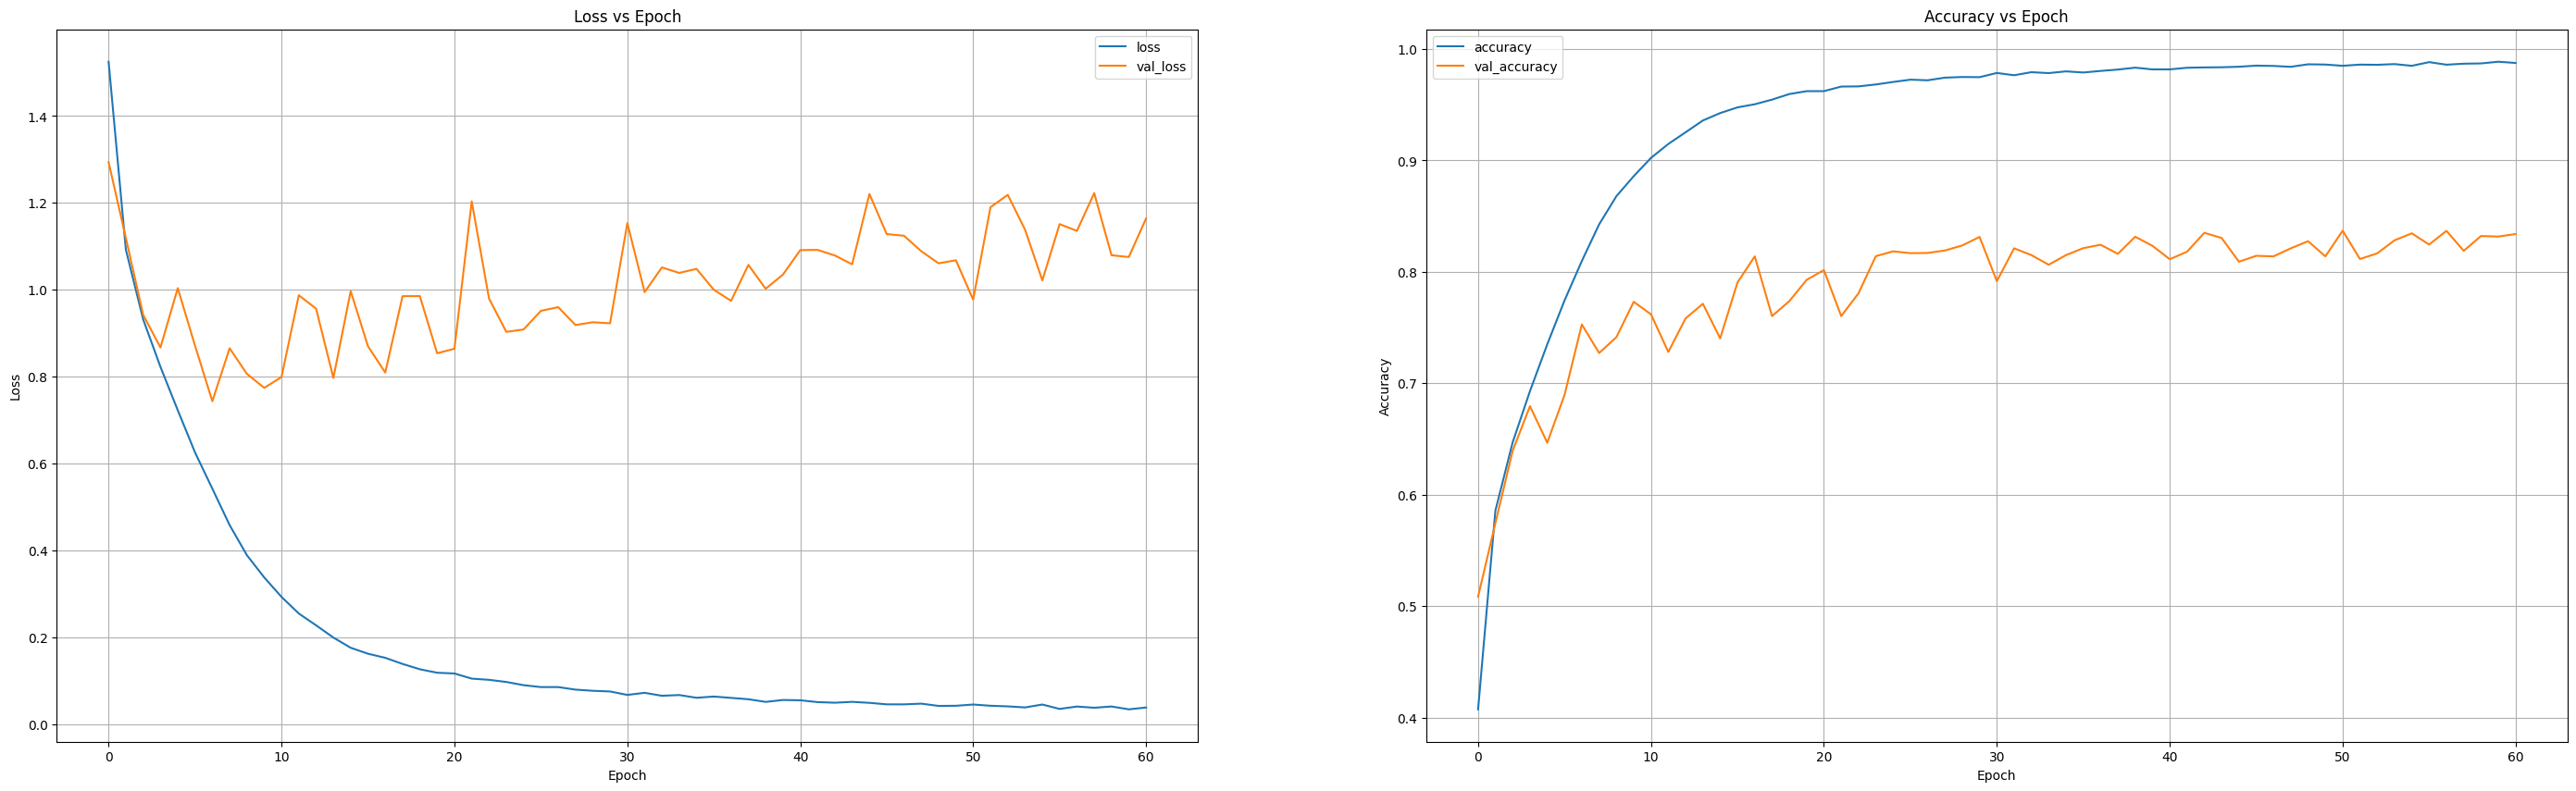

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.plot(history_callback_object.history["loss"], label="loss")
ax1.plot(history_callback_object.history["val_loss"], label="val_loss")
ax1.legend()
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Loss vs Epoch")
ax1.grid(True)
ax2.plot(history_callback_object.history["accuracy"], label="accuracy")
ax2.plot(history_callback_object.history["val_accuracy"], label="val_accuracy")
ax2.legend()
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Accuracy vs Epoch")
ax2.grid(True)

fig.set_figheight(10)
fig.set_figwidth(35)
plt.show()

In [ ]:
y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)
print(y_pred[0])

196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
1


In [ ]:
print("Accuracy of model on testing data: ", model.evaluate(X_test, y_test)[1] * 100, "%")


196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8319 - loss: 0.9562
Accuracy of model on testing data:  83.024001121521 %


In [ ]:
print("Accuracy of model on validation data: ", model.evaluate(X_valid, y_valid)[1] * 100, "%")

196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8353 - loss: 0.9590
Accuracy of model on validation data:  83.69600176811218 %


In [ ]:
accuracy = accuracy_score(y_test_labels, y_pred)
precision = precision_score(y_test_labels, y_pred, average="micro")
recall = recall_score(y_test_labels, y_pred, average="micro")
f1 = f1_score(y_test_labels, y_pred, average="micro")

print(f"Accuracy Score: {accuracy * 100:.2f}%")
print(f"Precision Score: {precision * 100:.2f}%")
print(f"Recall Score: {recall * 100:.2f}%")
print(f"F1 Score: {f1 * 100:.2f}%")

Accuracy Score: 83.02%
Precision Score: 83.02%
Recall Score: 83.02%
F1 Score: 83.02%


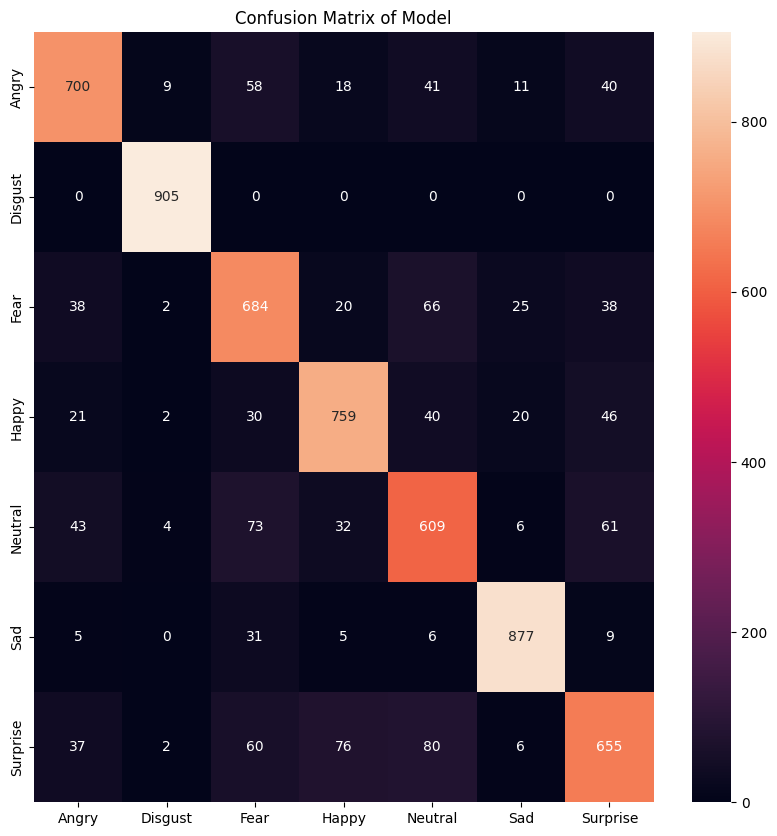

Model Classification Report
               precision    recall  f1-score   support

       Angry       0.83      0.80      0.81       877
     Disgust       0.98      1.00      0.99       905
        Fear       0.73      0.78      0.76       873
       Happy       0.83      0.83      0.83       918
     Neutral       0.72      0.74      0.73       828
         Sad       0.93      0.94      0.93       933
    Surprise       0.77      0.72      0.74       916

    accuracy                           0.83      6250
   macro avg       0.83      0.83      0.83      6250
weighted avg       0.83      0.83      0.83      6250



In [ ]:
fig = plt.figure(figsize=(10, 10))
plt.title("Confusion Matrix of Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")

cm = confusion_matrix(y_test_labels, y_pred)
cm_df = pd.DataFrame(cm, index=[i for i in emotions_classes_label], columns=[i for i in emotions_classes_label])

ax = sns.heatmap(cm_df, annot=True, fmt="d", cbar=True)
plt.show()

print("Model Classification Report\n", classification_report(y_test_labels, y_pred, target_names=emotions_classes_label))

# Pretrained_CNN - LSTM

In [ ]:
early_stopping = EarlyStopping(monitor="val_accuracy", patience=10, mode="auto", restore_best_weights=True)
reduce_learning_rate = ReduceLROnPlateau(monitor="val_accuracy", factor=0.5, verbose=1, min_lr=0.00001)

In [ ]:
def extract_features(X):
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(48, 48, 3))  # 3 channels for RGB
    base_model.trainable = False  # Freeze the base model
    features = base_model.predict(X)
    return features

# Since the model requires 3 channels, convert grayscale images to RGB.
def convert_to_rgb(X):
    return np.repeat(X, 3, axis=-1)

In [ ]:
X_train_rgb = convert_to_rgb(X_train)
X_valid_rgb = convert_to_rgb(X_valid)
X_test_rgb = convert_to_rgb(X_test)

# Extract features from training, validation, and test datasets
X_train_features = extract_features(X_train_rgb)
X_valid_features = extract_features(X_valid_rgb)
X_test_features = extract_features(X_test_rgb)

sequence_length = 1  # Adjust based on your sequence length
X_train_lstm = X_train_features.reshape(X_train_features.shape[0], sequence_length, -1)  # (num_samples, time_steps, features)
X_valid_lstm = X_valid_features.reshape(X_valid_features.shape[0], sequence_length, -1)
X_test_lstm = X_test_features.reshape(X_test_features.shape[0], sequence_length, -1)

/tmp/ipykernel_30/576287205.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(48, 48, 3))  # 3 channels for RGB


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step


In [ ]:
def create_cnn_lstm_model(input_shape):
    model = models.Sequential()  # Initialize the Sequential model
    model.add(layers.LSTM(128, return_sequences=True, input_shape=input_shape))  # First LSTM layer with sequences
    model.add(layers.Dropout(0.5))
    model.add(layers.LSTM(64, return_sequences=False))  # Second LSTM layer with reduced units
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(128, activation='relu'))  # Dense layer for additional learning
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(len(np.unique(y)), activation='softmax'))  # Final output layer
    return model

input_shape = (X_train_lstm.shape[1], X_train_lstm.shape[2])  # (time_steps, features)
cnn_lstm_model = create_cnn_lstm_model(input_shape)

In [ ]:
print("y_train shape:", y_train.shape)
print("y_valid shape:", y_valid.shape)

y_train shape: (49996,)
y_valid shape: (6250,)


In [ ]:
cnn_lstm_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
cnn_lstm_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 1, 128)         │     2,687,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,746,119 (10.48 MB)

 Trainable params: 2,746,119 (10.48 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
cnn_lstm_model.fit(X_train_lstm, y_train, validation_data=(X_valid_lstm, y_valid),
                   epochs=100, batch_size=32,
                   callbacks=[early_stopping, reduce_learning_rate])

Epoch 1/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.2328 - loss: 1.8669 - val_accuracy: 0.3536 - val_loss: 1.6588 - learning_rate: 0.0010
Epoch 2/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.3357 - loss: 1.6896 - val_accuracy: 0.3982 - val_loss: 1.5349 - learning_rate: 0.0010
Epoch 3/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.3695 - loss: 1.6052 - val_accuracy: 0.4219 - val_loss: 1.4623 - learning_rate: 0.0010
Epoch 4/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.3878 - loss: 1.5489 - val_accuracy: 0.4413 - val_loss: 1.4073 - learning_rate: 0.0010
Epoch 5/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.4019 - loss: 1.5134 - val_accuracy: 0.4518 - val_loss: 1.3783 - learning_rate: 0.0010
Epoch 6/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.4086 - loss: 1.4887 - val_accuracy: 0.4477 - val_loss: 1.3789 - learning_rate: 0.0010
Epoch 7/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accura

In [ ]:
cnn_lstm_model.fit(X_train_lstm, y_train, validation_data=(X_valid_lstm, y_valid),
                   epochs=100, batch_size=32,
                   callbacks=[early_stopping, reduce_learning_rate])

Epoch 1/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.6852 - loss: 0.8765 - val_accuracy: 0.6510 - val_loss: 1.0267 - learning_rate: 0.0010
Epoch 2/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.6873 - loss: 0.8653 - val_accuracy: 0.6429 - val_loss: 1.0273 - learning_rate: 0.0010
Epoch 3/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.6900 - loss: 0.8672 - val_accuracy: 0.6560 - val_loss: 1.0230 - learning_rate: 0.0010
Epoch 4/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.6929 - loss: 0.8589 - val_accuracy: 0.6546 - val_loss: 1.0177 - learning_rate: 0.0010
Epoch 5/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.6941 - loss: 0.8552 - val_accuracy: 0.6507 - val_loss: 1.0141 - learning_rate: 0.0010
Epoch 6/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.6939 - loss: 0.8564 - val_accuracy: 0.6602 - val_loss: 1.0146 - learning_rate: 0.0010
Epoch 7/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accura